# Customer Churn Analysis
### Telco Dataset | 7,032 Customer Records
**Goal:** Identify why customers churn and predict which customers are at risk using Python, SQL, and Machine Learning.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('telco_churn.csv')
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df.dropna(inplace=True)
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

print(f"Dataset: {df.shape[0]} rows, {df.shape[1]} columns")
print(f"Overall Churn Rate: {df['Churn'].mean()*100:.2f}%")

Dataset: 7032 rows, 21 columns
Overall Churn Rate: 26.58%


## Key SQL Findings
- 26.58% of customers churned overall — roughly 1 in 4 customers left
- Month-to-month customers churn at 43% vs only 3% for 2-year contract customers
- Churned customers pay around 13 dollars more per month on average ($74.44 vs $61.27)
- Fiber optic users churn at 42% vs only 19% for DSL users
- Senior citizens churn at 42% vs 24% for non-seniors
- Electronic check users churn at 45% — highest of any payment method
- Auto-pay customers churn at only 15-17% — huge difference
- Paperless billing customers churn at 33.57% vs 16.33% for non-paperless
- Churned customers use 3.13 services on average vs 3.45 for retained

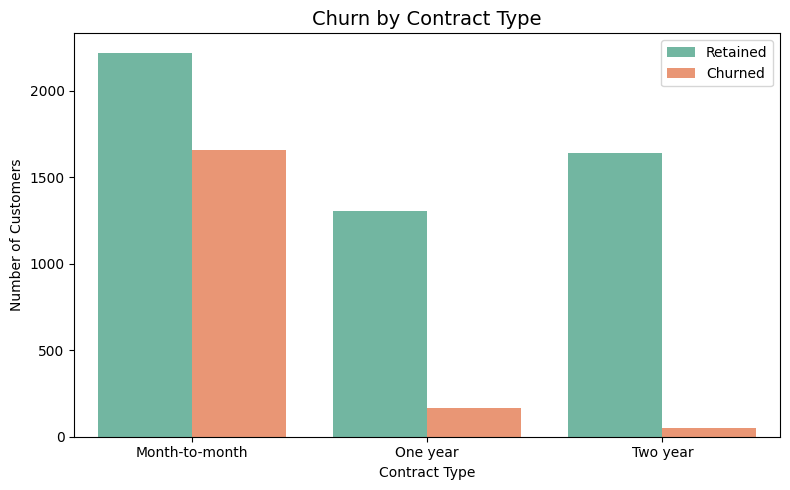

In [2]:
# Plot 1 - Churn by Contract Type
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='Contract', hue='Churn', palette='Set2')
plt.title('Churn by Contract Type', fontsize=14)
plt.xlabel('Contract Type')
plt.ylabel('Number of Customers')
plt.legend(labels=['Retained', 'Churned'])
plt.tight_layout()
plt.show()

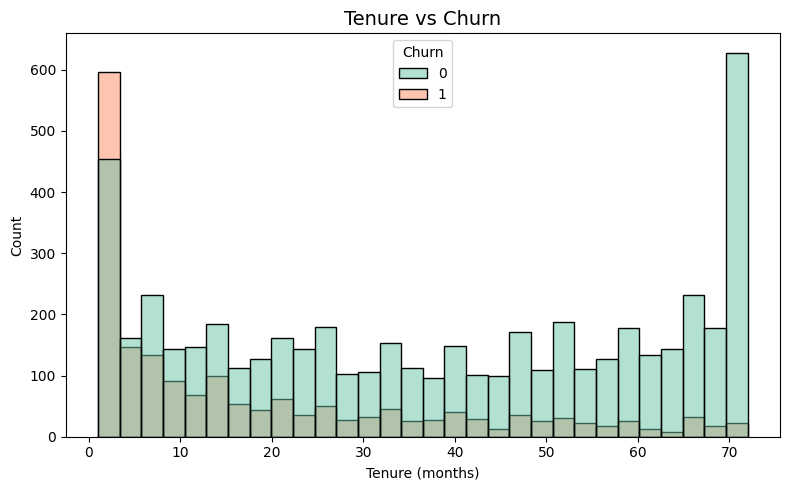

In [3]:
# Plot 2 - Tenure Distribution
plt.figure(figsize=(8,5))
sns.histplot(data=df, x='tenure', hue='Churn', bins=30, palette='Set2')
plt.title('Tenure vs Churn', fontsize=14)
plt.xlabel('Tenure (months)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

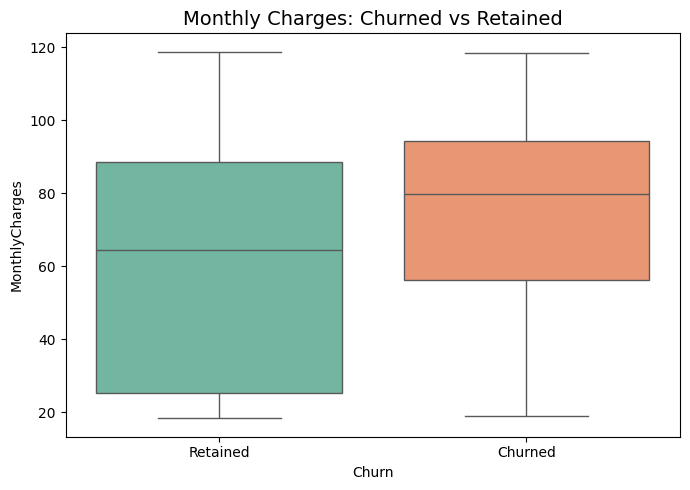

In [4]:
# Plot 3 - Monthly Charges Boxplot
plt.figure(figsize=(7,5))
sns.boxplot(data=df, x='Churn', y='MonthlyCharges', palette='Set2')
plt.title('Monthly Charges: Churned vs Retained', fontsize=14)
plt.xticks([0,1], ['Retained', 'Churned'])
plt.tight_layout()
plt.show()

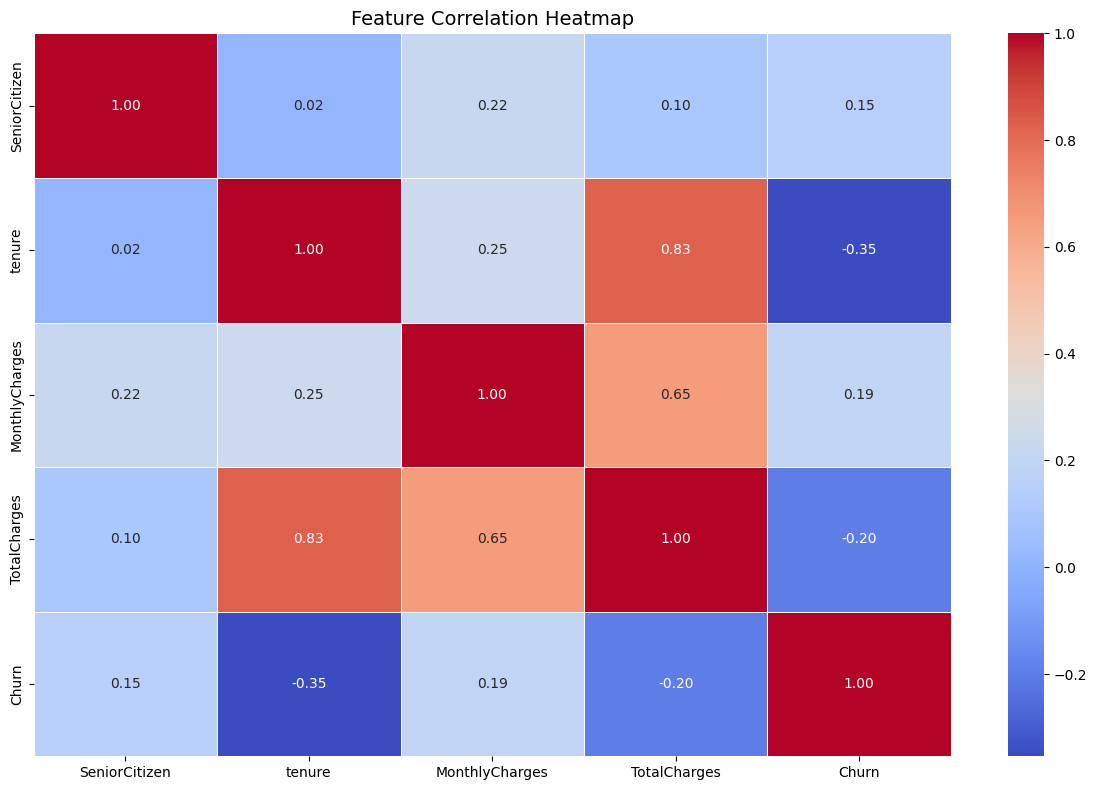

In [5]:
# Plot 4 - Correlation Heatmap
plt.figure(figsize=(12,8))
numeric_df = df.select_dtypes(include='number')
sns.heatmap(numeric_df.corr(), annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Feature Correlation Heatmap', fontsize=14)
plt.tight_layout()
plt.show()

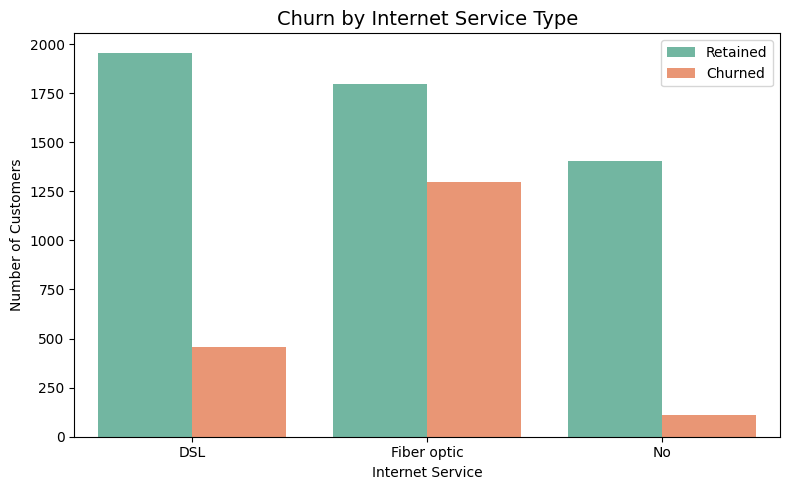

In [6]:
# Plot 5 - Churn by Internet Service
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='InternetService', hue='Churn', palette='Set2')
plt.title('Churn by Internet Service Type', fontsize=14)
plt.xlabel('Internet Service')
plt.ylabel('Number of Customers')
plt.legend(labels=['Retained', 'Churned'])
plt.tight_layout()
plt.show()

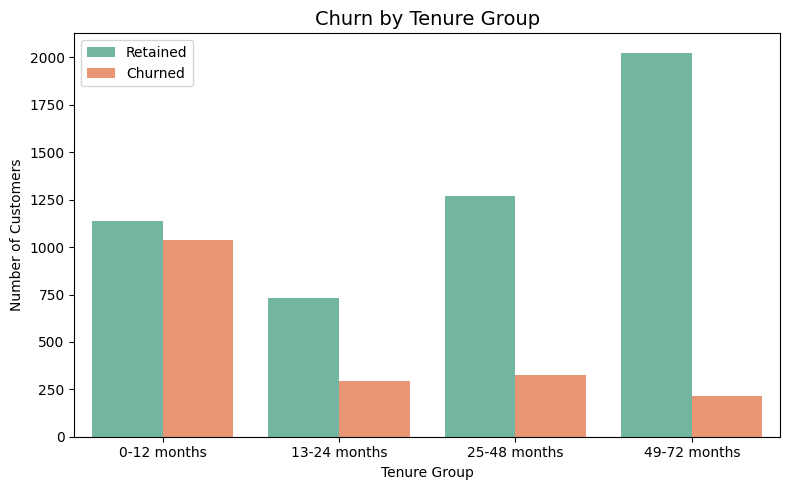

In [7]:
# Plot 6 - Churn by Tenure Group
df['tenure_group'] = pd.cut(df['tenure'], bins=[0,12,24,48,72], labels=['0-12 months','13-24 months','25-48 months','49-72 months'])
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='tenure_group', hue='Churn', palette='Set2')
plt.title('Churn by Tenure Group', fontsize=14)
plt.xlabel('Tenure Group')
plt.ylabel('Number of Customers')
plt.legend(labels=['Retained', 'Churned'])
plt.tight_layout()
plt.show()

## Machine Learning Model: Logistic Regression
We trained a Logistic Regression classifier to predict which customers are likely to churn.
- **Training set:** 80% of data (5,625 records)
- **Test set:** 20% of data (1,407 records)
- **Result:** 78.75% accuracy | AUC Score: 0.83

In [8]:
# ML Model
df_model = df.copy()
df_model.drop('customerID', axis=1, inplace=True)
df_model.drop('tenure_group', axis=1, inplace=True)

le = LabelEncoder()
cat_cols = df_model.select_dtypes(include='object').columns
for col in cat_cols:
    df_model[col] = le.fit_transform(df_model[col])

X = df_model.drop('Churn', axis=1)
y = df_model['Churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print(f"Accuracy: {accuracy_score(y_test, y_pred)*100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 78.75%

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1033
           1       0.63      0.49      0.55       374

    accuracy                           0.79      1407
   macro avg       0.73      0.69      0.71      1407
weighted avg       0.78      0.79      0.78      1407



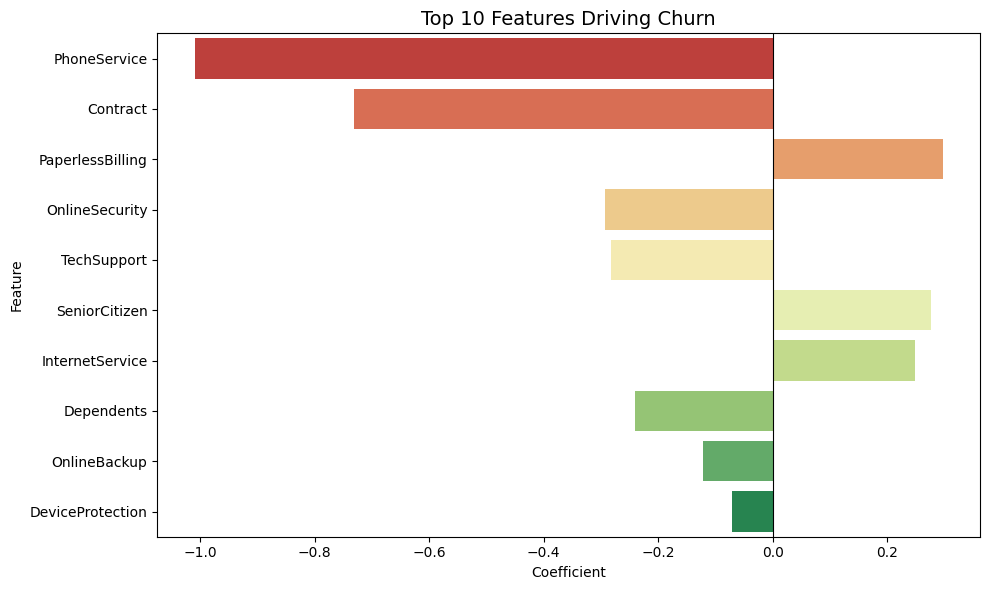

In [9]:
# Feature Importance
importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_[0]
}).sort_values('Coefficient', key=abs, ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(data=importance_df.head(10), x='Coefficient', y='Feature', palette='RdYlGn')
plt.title('Top 10 Features Driving Churn', fontsize=14)
plt.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

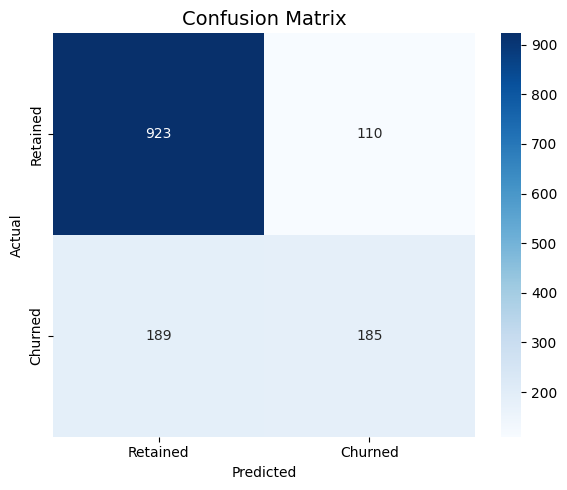

In [10]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Retained', 'Churned'],
            yticklabels=['Retained', 'Churned'])
plt.title('Confusion Matrix', fontsize=14)
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

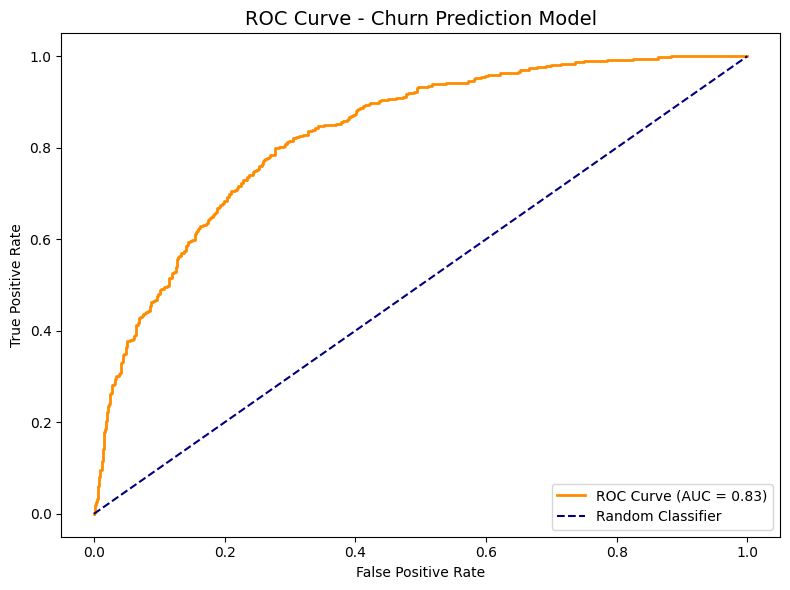

In [11]:
# ROC Curve
y_prob = model.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=1.5, linestyle='--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Churn Prediction Model', fontsize=14)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

## Business Recommendations
1. **Target month-to-month customers** with loyalty discounts at the 3-month mark
2. **Promote long-term contracts** — 2-year contract customers churn 14x less than month-to-month
3. **Encourage auto-pay setup** — auto-pay customers churn at only 15-17% vs 45% for electronic check users
4. **Flag new customers (0-12 months)** for proactive outreach — highest churn risk group
5. **Review fiber optic pricing** — 42% churn rate despite being a premium service suggests dissatisfaction
6. **Offer paperless billing incentives** — paperless customers churn at double the rate of non-paperless